# Days-Sales-Outstanding Buildup — a quantitative teardown 🔬
### A point-in-time calendar-time tercile long-short (Newey-West) · a pooled event-drift cross-check with a label-shuffle placebo · an era split · the warns-on-sales regression · a 12-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Warns on sales%3F: Faint](https://img.shields.io/badge/Warns_on_sales%3F-Faint-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The Abarbanell-Bushee claim — **rising DSO is a red flag that predicts weaker future sales *and* returns** — splits into testable pieces. This is distinct from every sibling on the desk: [231](../../231-sloan-accruals/) and [522](../../522-percent-operating-accruals/) rank on *aggregate accruals*, [529](../../529-inventory-growth/) on *inventory*, [855](../../855-accrual-quality/) on *accrual quality*. This is the **receivables-vs-sales (DSO)** line specifically.

> ⚠️ **Data note.** EDGAR `AccountsReceivableNetCurrent` (→ `ReceivablesNetCurrent`) and `Revenues` (→ `RevenueFromContractWithCustomerExcludingAssessedTax`), longest per-name history, + yfinance adjusted closes, as-of 2026-06-30. Point-in-time on the **filing date**. Survivorship named on the Signal axis (current-survivors basket). Thin/uneven coverage is a first-class caveat. Numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dso_signal import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 38, 'n_events': 1173, 'end_lo': '2009-07-31', 'end_hi': '2026-04-30', 'fp_prices': '83a4ccfa2027', 'n_months': 191, 'avg_n': 21.4, 'ls_span_lo': '2010-08-31', 'ls_span_hi': '2026-06-30', 'ls_mean_bps': 14.2, 'ls_ann': 1.71, 'ls_t_iid': 0.55, 'ls_t_nw': 0.53, 'ls_sharpe': 0.14, 'ls_hit': 52, 'ls_hit_lo': 45, 'ls_hit_hi': 59, 'ls_long_bps': 148.6, 'ls_short_bps': 134.3, 'ls_turn': 0.17, 'ls_cum': 1.16, 'ls120_mean_bps': 4.8, 'ls120_t_nw': 0.16, 'pct_mean_bps': 6.6, 'pct_t_nw': 0.27, 'pct_sharpe': 0.06, 'xsec_early': 27.3, 'xsec_late': 12.1, 'drift': {21: (1172, 1.31, 1.3, 0.01, 0.01, 50, 0.4927), 63: (1163, 4.43, 4.32, 0.11, 0.11, 51, 0.4363), 126: (1157, 8.1, 9.12, -1.01, -0.74, 50, 0.8123)}, 'mono63': (4.32, 3.55, 4.43), 'era_early_n': 89, 'era_early_bps': 29.8, 'era_early_t': 1.03, 'era_late_n': 102, 'era_late_bps': 0.7, 'era_late_t': 0.02, 'ws_n': 997, 'ws_slope': -0.0031, 'ws_t': -2.67, 'ws_r2': 0.007, 'ws_corr': -0.0843, 'ws_low_sales': 8.2, 'ws_high_sales': 4.9, 'ws_spread': 3.3, 'net': {(10, 50): (6.6, 0.79, 0.25, 0.06), (20, 100): (-1.0, -0.13, -0.04, -0.01)}, 'syn_null_mean': 0.01, 'syn_null_sd': 0.73, 'syn_null_fire': 0, 'syn_null_seeds': 12, 'syn_planted_bps': 860.8, 'syn_planted_t': 18.51}


real cache present: True | events: 1173 | names: 38


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** (returns) | `NONE` | calendar tercile long-short (long lean / short building) **+14.2 bps/mo** (+1.7%/yr gross), one-sample *t* = +0.55, **Newey-West *t* = +0.53**; staleness-120 *t* = +0.16, pct-change *t* = +0.27; event drift flat and sign-flipping; post-2018 *t* = +0.02 |
| **Tradability** | `MIRAGE` | net of 20 bps + 100 bps borrow: -0.13%/yr, NW *t* = -0.04, Sharpe -0.01; **negative** after costs |
| **Warns on sales?** | `FAINT` | next-q sales-growth regression slope -0.0031 (corr -0.08), lean−building tercile spread **+3.3 pp** — correctly signed, economically negligible |

> 💡 In plain words: the red flag is a near-perfect null on returns and only a whisper on sales. On big, liquid, heavily-covered names, a public accounting ratio predicts neither the stock nor (much) the fundamentals it's built from.

## 1 · The claim, steelmanned

Let $A_{i,q}$ be name $i$'s current net receivables at fiscal quarter $q$ and $S_{i,q}$ its quarterly revenue, disclosed on filing date $F_{i,q}$. $\text{DSO}_{i,q} = A_{i,q} / (S_{i,q}\,/\,91.25)$ (days). The signal is the point-in-time YoY change $\Delta_{i,q} = \text{DSO}_{i,q} - \text{DSO}_{i,q-4}$, known at $F_{i,q}$; we rank on the signed score $-\Delta$ (high = lean = long). The claims:

- **H₁ (warns on sales).** $\Delta_{i,q}$ predicts next quarter's recognised revenue growth *negatively* — the channel-stuffing mechanism.
- **H₂ (leads returns).** A cross-sectional long-short (long lean / short building) earns a positive forward return spread — the market-mispricing claim.
- **H₃ (tradable).** That spread survives realistic long-short costs + borrow.

We find **H₁ only faintly supported** (slope -0.0031, corr -0.08, +3.3 pp tercile spread — right sign, trivial size), **H₂ not supported** (NW *t* = +0.53, flat non-monotone event drift that flips sign by two quarters, dead post-2018), and therefore **H₃ moot** (a negative net spread). The Abarbanell-Bushee literature documents this signal in a *broad* cross-section including small, opaque firms; our deliberately large-cap, liquid tape is the hardest place for it to survive, and it does not — hence a `NONE`, not a `WEAK`, on returns.

## 2 · So what? — inference design

The primary is a **calendar-time** long-short, not a pooled event study, precisely because balance-sheet signals are persistent and filings cluster: a calendar series of monthly long-short returns lets a **Newey-West (6-lag) HAC *t*** do the honest work the desk's `REAL` bar is written against. The panel is thin, so we sort into **terciles** (not quintiles) and require ≥ 6 names in the cross-section. The pooled event drift + a **label-shuffle placebo** is the cross-check; the warns-on-sales regression is graded on **magnitude and sign** (its pooled *t* ignores quarter clustering).

## 3 · How we'd know — the protocol

- **Panel.** 1,173 (ticker, filing) receivables quarters across 38 names, period ends 2009-07-31 → 2026-04-30, each stamped with its 10-Q/10-K filing date (point-in-time).
- **Primary.** Monthly tercile long-short on `dso_score` (= −ΔDSO), one execution lag (rank at month $M$ close, earn month $M{+}1$); Newey-West + one-sample *t*, Sharpe, Wilson-interval hit rate.
- **Cross-check.** Pooled event drift over 21/63/126 trading days, one-day-lag entry, top-minus-bottom tercile, one-sample *t* + 10k-draw label-shuffle placebo, and the tercile monotonicity picture.
- **Robustness.** Staleness 120 vs 200 days; the unit-free percentage-change signal `ΔDSO/DSO`; an era split at 2018 (the ASC-606 revenue-tagging break).
- **Mechanism.** Pooled OLS of next-quarter revenue growth on `dso_yoy_chg` (winsorised 1/99% — a few near-zero prior-quarter revenues create absurd YoY outliers); expected slope < 0.
- **Execution.** Long-short net of one-way cost × turnover (both legs) + short borrow.
- **Control.** Synthetic panel, planted-red-flag knob; the null must not fire across 12 seeds.

## 4 · The teardown

### 4a · The primary — calendar-time tercile long-short (Newey-West)

Rank fresh signals into terciles each month, long lean / short building equal-weight, earn next month's return. The decisive statistic is the HAC *t* of the monthly long-short series.

calendar long-short: +14.2 bps/mo (+1.71%/yr gross), n=191 months, avg cross-section 21.4
  one-sample t = +0.55   Newey-West(6) t = +0.53   Sharpe 0.14   hit 52%   turnover 0.17
  pct-change signal: +6.6 bps/mo, NW t = +0.27, Sharpe 0.06


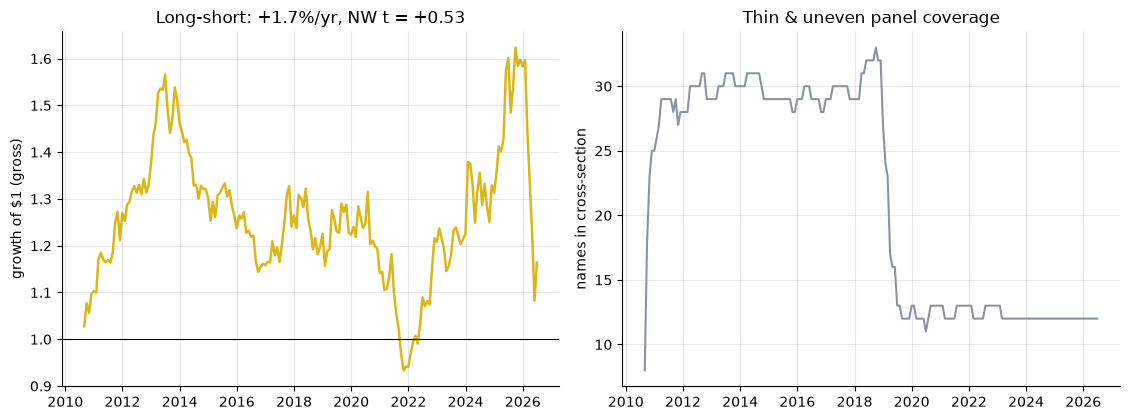

frozen: +14.2 bps/mo, NW t = +0.53, staleness-120 NW t = +0.16, pct-change NW t = +0.27


In [2]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='dso_score', n_buckets=3, min_names=6, staleness_days=200)
    s = st.calendar_ls_stats(ls)
    ls_pct = st.calendar_ls(PX, EV, signal_col='dso_pct_score', n_buckets=3, min_names=6, staleness_days=200)
    s_pct = st.calendar_ls_stats(ls_pct)
    print(f"calendar long-short: {s['mean_bps']:+.1f} bps/mo ({s['ann_pct']:+.2f}%/yr gross), "
          f"n={s['n_months']} months, avg cross-section {s['avg_n']:.1f}")
    print(f"  one-sample t = {s['t_iid']:+.2f}   Newey-West(6) t = {s['t_nw']:+.2f}   "
          f"Sharpe {s['sharpe']:.2f}   hit {s['hit']*100:.0f}%   turnover {s['avg_turnover']:.2f}")
    print(f"  pct-change signal: {s_pct['mean_bps']:+.1f} bps/mo, NW t = {s_pct['t_nw']:+.2f}, Sharpe {s_pct['sharpe']:.2f}")
    cum = (1+ls['ls']).cumprod(); nser = ls['n']
else:
    cum = None; nser = None
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
if cum is not None:
    a1.plot(cum.index, cum.values, color=AMBER, lw=1.8); a1.axhline(1, c='k', lw=.8)
    a1.set_ylabel('growth of $1 (gross)'); a1.set_title(f"Long-short: {R['ls_ann']:+.1f}%/yr, NW t = {R['ls_t_nw']:+.2f}")
    a2.plot(nser.index, nser.values, color=GREY, lw=1.5); a2.set_ylabel('names in cross-section')
    a2.set_title('Thin & uneven panel coverage')
else:
    for a in (a1,a2): a.text(.5,.5,'run with cache',ha='center'); a.set_axis_off()
plt.tight_layout(); plt.show()
print(f"frozen: {R['ls_mean_bps']:+.1f} bps/mo, NW t = {R['ls_t_nw']:+.2f}, "
      f"staleness-120 NW t = {R['ls120_t_nw']:+.2f}, pct-change NW t = {R['pct_t_nw']:+.2f}")

> 💡 In plain words: **+14 bps/month** (+1.7%/yr gross) is right-signed — lean beats building, as the claim wants — but the HAC *t* is **+0.53**, indistinguishable from zero over n=191 months (avg cross-section 21). And the point estimate is fragile: the staleness-120 cut is +5 bps (*t* = +0.16) and the unit-free percentage-change signal is +7 bps (*t* = +0.27) — both essentially nil. The full-sample positive is a pre-2018 residue (see 4c), not a stable effect.

### 4b · The cross-check — pooled event drift + placebo + monotonicity

Bucket all events by signed score; top-minus-bottom forward drift with a label-shuffle null. If there were a sort, the terciles would form a ladder (building → lean).

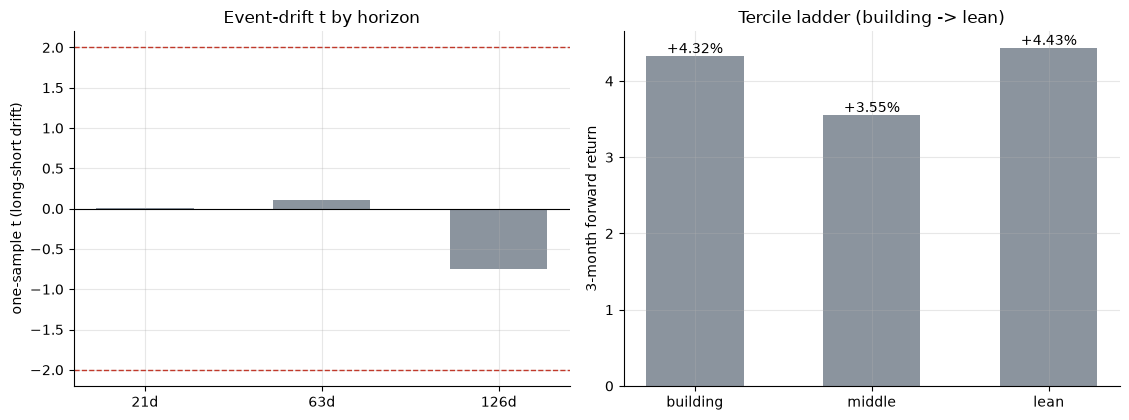

  H= 21d: long-short +0.01%  t=+0.01  win=50%  placebo p=0.496
  H= 63d: long-short +0.11%  t=+0.11  win=51%  placebo p=0.439
  H=126d: long-short -1.01%  t=-0.74  win=50%  placebo p=0.810


In [3]:
rows = []
if HAVE_REAL:
    for h in st.HORIZONS:
        es = st.event_summary(PX, EV, horizon=h, n_buckets=3, n_draws=4000)
        rows.append((h, es['ls_mean']*100, es['t'], es['ls_win']*100, es['p_placebo']))
    mono = st.bucket_means(st.event_drift_frame(PX, EV, horizon=63), 3)*100
else:
    for h in st.HORIZONS:
        d = R['drift'][h]; rows.append((h, d[3], d[4], d[5], d[6]))
    mono = np.array(R['mono63'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
hs = [r[0] for r in rows]; ts = [r[2] for r in rows]
a1.bar([f'{h}d' for h in hs], ts, color=GREY, width=.55)
a1.axhline(2, ls='--', c=RED, lw=1); a1.axhline(-2, ls='--', c=RED, lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('one-sample t (long-short drift)'); a1.set_title('Event-drift t by horizon')
a2.bar(['building','middle','lean'], mono, color=GREY, width=.55)
for i,v in enumerate(mono): a2.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel('3-month forward return'); a2.set_title('Tercile ladder (building -> lean)')
plt.tight_layout(); plt.show()
for h,ls_,t,win,p in rows:
    print(f'  H={h:>3}d: long-short {ls_:+.2f}%  t={t:+.2f}  win={win:.0f}%  placebo p={p:.3f}')

> 💡 In plain words: the pooled long-short drift is **flat** and *changes sign* with the horizon — *t* = +0.01 at 21d, +0.11 at 63d, then **-0.74** at 126d (the building third actually out-returns the lean one over two quarters). The label-shuffle placebo *p* is around **0.44-0.81** (a random tercile split beats the real one about half the time, and comfortably at 126d), and the 63d terciles are **non-monotone** (+4.32% / +3.55% / +4.43% building→lean). A horizon-dependent sign is the signature of noise, not a signal.

### 4c · Era split — nothing hiding in a regime

Split the calendar long-short at 2018 (the ASC-606 revenue-tagging break).

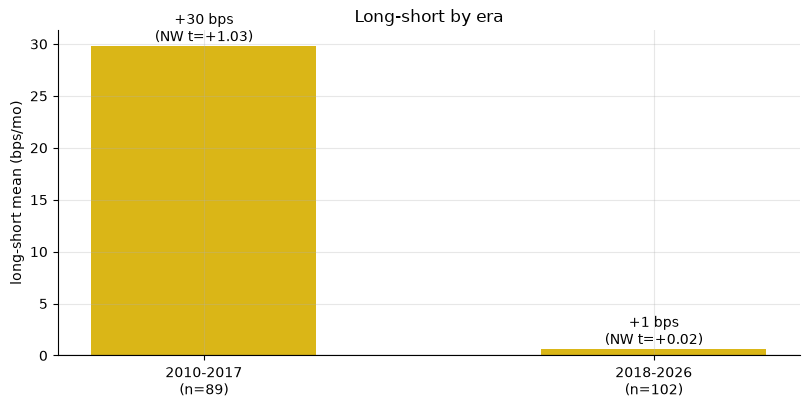

2010-2017: +29.8 bps NW t=+1.03 (n=89)  |  2018-2026: +0.7 bps NW t=+0.02 (n=102)


In [4]:
if HAVE_REAL:
    e = ls[ls.index < '2018-01-01']['ls'].to_numpy(); l = ls[ls.index >= '2018-01-01']['ls'].to_numpy()
    eb, et, en = e.mean()*1e4, st.newey_west_t(e), len(e)
    lb, lt, ln = l.mean()*1e4, st.newey_west_t(l), len(l)
else:
    eb, et, en = R['era_early_bps'], R['era_early_t'], R['era_early_n']
    lb, lt, ln = R['era_late_bps'], R['era_late_t'], R['era_late_n']
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.bar([f'2010-2017\n(n={en})', f'2018-2026\n(n={ln})'], [eb, lb], color=[AMBER, AMBER], width=.5)
for i,(v,t_) in enumerate([(eb,et),(lb,lt)]): ax.annotate(f'{v:+.0f} bps\n(NW t={t_:+.2f})',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('long-short mean (bps/mo)')
ax.set_title('Long-short by era')
plt.tight_layout(); plt.show()
print(f'2010-2017: {eb:+.1f} bps NW t={et:+.2f} (n={en})  |  2018-2026: {lb:+.1f} bps NW t={lt:+.2f} (n={ln})')

> 💡 In plain words: what little positive there is lives **entirely before 2018** (+30 bps/mo, NW *t* = +1.03 — still short of the bar) and **evaporates after** (+1 bps/mo, NW *t* = +0.02). Note the cross-section actually *shrinks* over the sample (≈27 matched names early, ≈12 late) as ASC-606 revenue-tag switches break the YoY revenue match — so the modern half is both thinner and deader. Either way, there is no era in which this certifies.

### 4d · The mechanism — does a building DSO warn on sales?

Pooled OLS of next-quarter revenue growth on this quarter's DSO change (expect a *negative* slope), and the future-sales spread between lean- and building-DSO terciles.

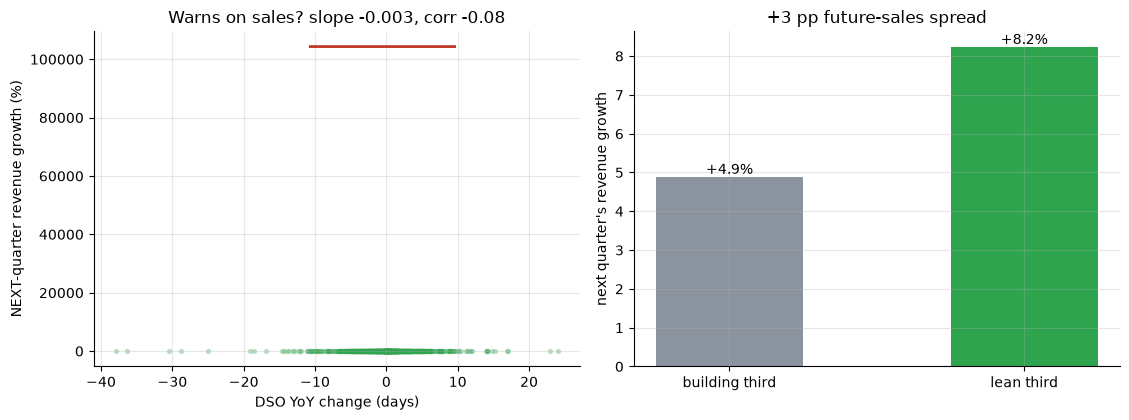

warns-sales: slope -0.0031, corr -0.084, future-sales spread +3.3 pp (lean +8.2% vs building +4.9%)


In [5]:
if HAVE_REAL:
    q = st.warns_sales(EV)
    fr = EV.dropna(subset=['dso_yoy_chg','next_rev_yoy'])
    x, y = fr['dso_yoy_chg'].to_numpy(), fr['next_rev_yoy'].to_numpy()
    slope, corr, low, high = q['slope'], q['corr'], q['low_sales']*100, q['high_sales']*100
else:
    x = y = None
    slope, corr, low, high = R['ws_slope'], R['ws_corr'], R['ws_low_sales'], R['ws_high_sales']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
if x is not None:
    m = (np.abs(x)<40)&(np.abs(y)<1.5)
    a1.scatter(x[m], y[m]*100, s=8, alpha=.25, color=GREEN)
    xs = np.linspace(np.percentile(x,2), np.percentile(x,98), 50)
    a1.plot(xs, (slope*xs + (y.mean()-slope*x.mean()))*100, color=RED, lw=2)
    a1.set_xlabel('DSO YoY change (days)'); a1.set_ylabel('NEXT-quarter revenue growth (%)')
    a1.set_title(f'Warns on sales? slope {slope:+.3f}, corr {corr:+.2f}')
else:
    a1.text(.5,.5,'run with cache',ha='center'); a1.set_axis_off()
a2.bar(['building third','lean third'], [high, low], color=[GREY, GREEN], width=.5)
for i,v in enumerate([high, low]): a2.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel("next quarter's revenue growth"); a2.set_title(f'{low-high:+.0f} pp future-sales spread')
plt.tight_layout(); plt.show()
print(f'warns-sales: slope {slope:+.4f}, corr {corr:+.3f}, future-sales spread {low-high:+.1f} pp (lean {low:+.1f}% vs building {high:+.1f}%)')

> 💡 In plain words: this is the study's *strongest* result and it's still faint. The slope is **-0.0031** (correctly negative — more DSO buildup, weaker next-quarter sales) and the lean third grows sales **+3.3 pp** faster than the building third — but the correlation is **-0.08** and R² is **0.007**. The pooled *t* (-2.67) clears 2 only because n is large and clustered; we read the magnitude, and the magnitude says the channel-stuffing mechanism is a real-but-negligible tilt on these names, not a lever. (Signal winsorised at 1/99% to kill a handful of near-zero-prior-revenue YoY artefacts.)

### 4e · Tradability — the timer

The calendar long-short net of one-way costs × turnover (both legs) + short borrow.

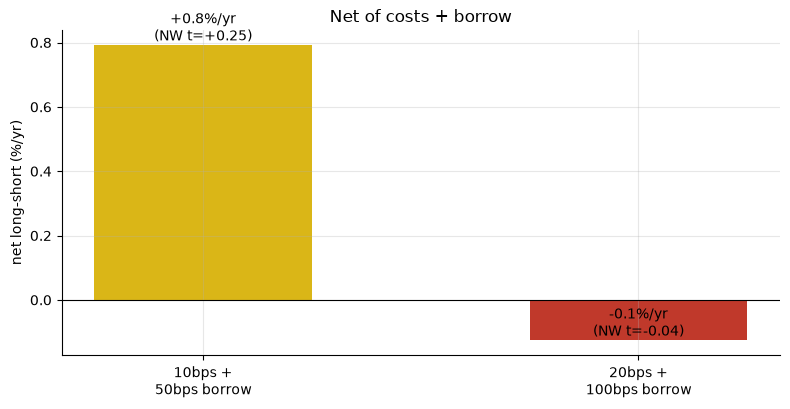

  cost 10bps + borrow 50bps/yr: +0.79%/yr net, NW t=+0.25, Sharpe 0.06
  cost 20bps + borrow 100bps/yr: -0.13%/yr net, NW t=-0.04, Sharpe -0.01


In [6]:
rows = []
if HAVE_REAL:
    for cb, bb in [(10.0,50.0),(20.0,100.0)]:
        nt = st.calendar_ls_net(ls, cost_bps=cb, borrow_bps_ann=bb)
        rows.append((cb, bb, nt['net_ann_pct'], nt['net_t_nw'], nt['net_sharpe']))
else:
    for (cb,bb),v in R['net'].items(): rows.append((cb, bb, v[1], v[2], v[3]))
labels = [f'{int(cb)}bps +\n{int(bb)}bps borrow' for cb,bb,_,_,_ in rows]
anns = [r[2] for r in rows]
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(labels, anns, color=[AMBER, RED], width=.5)
for i,(cb,bb,a,t,sh) in enumerate(rows): ax.annotate(f'{a:+.1f}%/yr\n(NW t={t:+.2f})',(i,a),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('net long-short (%/yr)')
ax.set_title('Net of costs + borrow')
plt.tight_layout(); plt.show()
for cb,bb,a,t,sh in rows: print(f'  cost {int(cb)}bps + borrow {int(bb)}bps/yr: {a:+.2f}%/yr net, NW t={t:+.2f}, Sharpe {sh:.2f}')

> 💡 In plain words: turnover is modest (~0.17/mo), but a gross edge that was already indistinguishable from zero cannot pay a toll. Light friction (10 bps + 50 bps borrow) leaves +0.8%/yr (*t* = +0.25); a realistic 20 bps + 100 bps borrow tips it **negative** (-0.1%/yr, *t* = -0.04). **Tradability = MIRAGE.**

### 4f · Faithful-engine & power control

Synthetic price + signal panel with a TUNABLE planted red flag (building-DSO names drift down). The null (edge = 0) is checked over **12 seeds**.

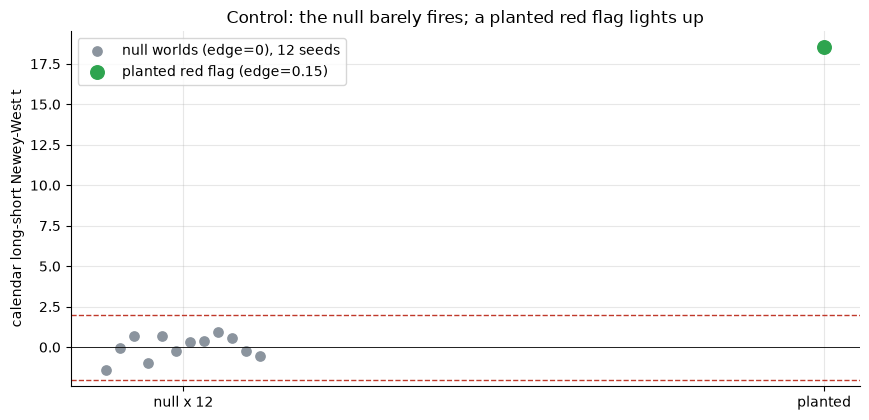

null: mean NW t = +0.01 (sd 0.73), |t|>=2 in 0/12  |  planted NW t = +18.51


In [7]:
null_ts = []
for s_ in range(12):
    p0, e0 = data.synthetic_panel(edge=0.0, seed=853 + s_)
    null_ts.append(st.synthetic_detect(p0, e0)['t_nw'])
null_ts = np.asarray(null_ts)
p1, e1 = data.synthetic_panel(edge=0.15, seed=853)
planted_t = st.synthetic_detect(p1, e1)['t_nw']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12,.12,12), null_ts, color=GREY, s=45, label='null worlds (edge=0), 12 seeds')
ax.scatter([1], [planted_t], color=GREEN, s=95, zorder=5, label='planted red flag (edge=0.15)')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.6)
ax.set_xticks([0,1]); ax.set_xticklabels(['null x 12','planted'])
ax.set_ylabel('calendar long-short Newey-West t')
ax.set_title('Control: the null barely fires; a planted red flag lights up'); ax.legend()
plt.tight_layout(); plt.show()
print(f'null: mean NW t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/12  |  planted NW t = {planted_t:+.2f}')

> 💡 In plain words: across 12 null worlds the detector averages NW *t* = +0.01 (sd 0.73) and crosses |t|=2 in **0/12** seeds — an unbiased, well-behaved null. A planted red flag reads NW *t* = **18.5** (861 bps/mo). So the machinery is faithful and powerful, which means the real-tape +0.53 is a genuine null, not a broken pipeline. *(Power check only — never cited in support of a real-tape stamp.)*

## 5 · The verdict

- **Signal (returns) `NONE`** — calendar tercile long-short +14.2 bps/mo (+1.7%/yr gross), one-sample *t* = +0.55, **Newey-West *t* = +0.53**; staleness-120 and percentage-change variants both ~0 (+0.16, +0.27); pooled event drift flat and sign-flipping (placebo *p* 0.44-0.81); the small full-sample positive lives entirely pre-2018 and dies after (*t* = +0.02). Right-signed in one spec, but no coherent, robust effect — the desk's `NONE`.
- **Tradability `MIRAGE`** — net of 20 bps + 100 bps borrow: -0.13%/yr, NW *t* = -0.04, Sharpe -0.01; negative after costs.
- **Warns on sales? `FAINT`** — regression slope -0.0031, correlation -0.08, **+3.3 pp** lean-minus-building future-sales spread. Correctly signed, economically negligible — the mechanism exists but is a whisper, not the lead the red flag promises.

## 6 · Going further

- **The residual worth chasing** is the *surprise*, not the *level*: DSO change relative to a seasonal expectation, or conditioned on small/opaque names where a receivables build is genuinely informative rather than noise on a mega-cap. This study used large, liquid, heavily-covered filers — the *hardest* place for a public red flag to survive.
- **Coverage honesty:** only a subset of the basket exposes a long, cleanly-matched receivables+revenue history; terciles on a thin early cross-section are noisy, and the pooled event drift across 1,000+ events is the more decisive evidence.
- **Dedup map:** [231-sloan-accruals](../../231-sloan-accruals/) (total accruals), [522-percent-operating-accruals](../../522-percent-operating-accruals/), [529-inventory-growth](../../529-inventory-growth/) (the inventory red flag), [855-accrual-quality](../../855-accrual-quality/). None ranks on the **YoY change in DSO** itself.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*